# 15. MCMC

**Статус:** завершено

MCMC строит цепь Маркова, стационарное распределение которой равно целевому распределению. Это позволяет семплировать из сложных posterior, где нормировочная константа неизвестна.

## Metropolis-Hastings

Для proposal $q(y|x)$ алгоритм принимает переход $x\to y$ с вероятностью

$$\alpha(x,y)=\min\left(1,\frac{\pi(y)q(x|y)}{\pi(x)q(y|x)}\right).$$

Для симметричного random-walk proposal $q(y|x)=q(x|y)$ отношение proposal сокращается. Нам достаточно знать целевую плотность с точностью до константы.

Практические понятия: burn-in удаляет начальную адаптацию, autocorrelation показывает зависимость соседних samples, ESS оценивает количество независимой информации в коррелированной цепи.

In [1]:
import os
import sys
from pathlib import Path
os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib-cache")
project_root = Path.cwd().resolve()
while not (project_root / "Scripts").exists():
    if project_root.parent == project_root:
        raise RuntimeError("Не удалось найти корень проекта с папкой Scripts.")
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.precision", 4)

from Scripts.mcmc import (
    calculate_autocorrelation,
    estimate_effective_sample_size,
    generate_logistic_regression_data,
    make_logistic_regression_log_posterior,
    plot_autocorrelation,
    plot_mcmc_trace_and_histogram,
    run_random_walk_metropolis_sampler,
    unnormalized_mixture_log_density,
)
from scipy.stats import norm

## 1. Семплирование из бимодальной смеси

,Показатель,Значение
0,acceptance rate,0.6967
1,posterior mean,0.0962
2,posterior std,2.1837
3,ESS estimate,481.1111


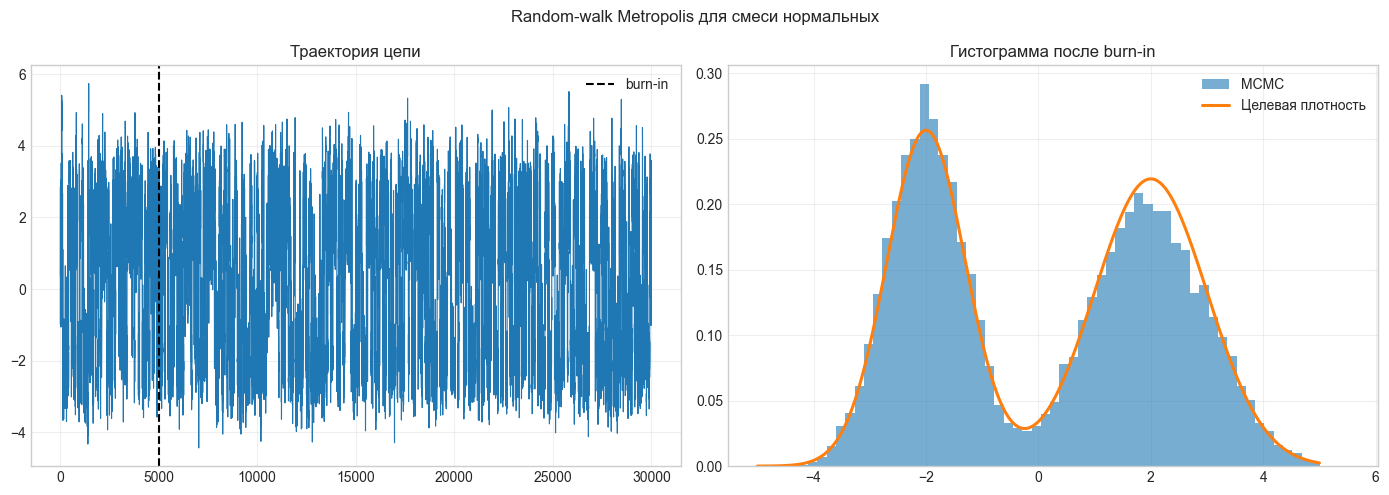

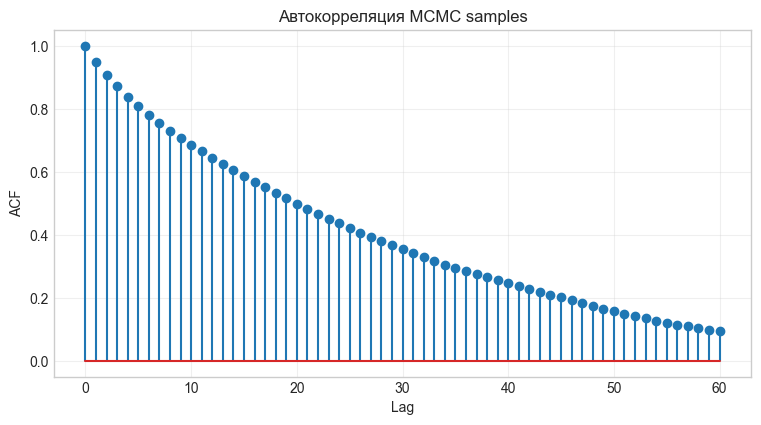

In [2]:
samples, acceptance_rate = run_random_walk_metropolis_sampler(
    unnormalized_mixture_log_density, 0.0, 30000, 1.0, random_seed=123
)
burn_in = 5000
grid = np.linspace(-5, 5, 800)
target_density = 0.45 * norm.pdf(grid, -2.0, 0.7) + 0.55 * norm.pdf(grid, 2.0, 1.0)
plot_mcmc_trace_and_histogram(samples, burn_in, grid, target_density, "Random-walk Metropolis для смеси нормальных");
acf = calculate_autocorrelation(samples[burn_in:], 60)
plot_autocorrelation(acf, "Автокорреляция MCMC samples");

post = samples[burn_in:]
pd.DataFrame({"Показатель": ["acceptance rate", "posterior mean", "posterior std", "ESS estimate"], "Значение": [acceptance_rate, post.mean(), post.std(), estimate_effective_sample_size(post,80)]})

Acceptance rate около `0.6967`, но ESS всего около `481` из 25 тысяч samples после burn-in. Причина — бимодальность: цепь может долго сидеть в одной моде и редко перескакивать в другую. В MCMC важно не только принимать много шагов, но и хорошо перемешиваться по всему распределению.

## 2. Масштаб proposal и смешивание

In [3]:
rows=[]
for scale in [0.15, 1.0, 5.0]:
    s, acc = run_random_walk_metropolis_sampler(unnormalized_mixture_log_density, 0.0, 30000, scale, random_seed=123)
    rows.append({"proposal std": scale, "acceptance rate": acc, "ESS": estimate_effective_sample_size(s[5000:],80), "mean": s[5000:].mean()})
pd.DataFrame(rows)

,proposal std,acceptance rate,ESS,mean
0,0.15,0.9457,166.2659,-0.5434
1,1.00,0.6967,481.1111,0.0962
2,5.00,0.3579,3666.9814,0.2217


Малый proposal имеет высокий acceptance (`0.9457`), но низкий ESS: цепь движется слишком мелкими шагами. Большой proposal принимает меньше (`0.3579`), зато ESS выше, потому что цепь лучше перескакивает между областями. Оптимальный масштаб — баланс между частотой принятия и дальностью движения.

## 3. Байесовская оценка параметра логистической регрессии

In [4]:
x, y = generate_logistic_regression_data(250, 0.0, 1.7, random_seed=77)
log_posterior = make_logistic_regression_log_posterior(x, y, prior_std=3.0)
beta_samples, beta_acceptance = run_random_walk_metropolis_sampler(log_posterior, 0.0, 25000, 0.25, random_seed=88)
beta_post = beta_samples[5000:]
pd.DataFrame({
    "Показатель": ["acceptance", "posterior mean beta", "2.5%", "97.5%", "ESS"],
    "Значение": [beta_acceptance, beta_post.mean(), np.quantile(beta_post,.025), np.quantile(beta_post,.975), estimate_effective_sample_size(beta_post,80)]
})

,Показатель,Значение
0,acceptance,0.6586
1,posterior mean beta,1.4805
2,2.5%,1.0766
3,97.5%,1.9230
4,ESS,2570.2993


Posterior mean для $\beta$ около `1.4805`, 95% credible interval примерно `[1.0766, 1.9230]`. Истинное значение в симуляции было `1.7`, и оно лежит внутри интервала. Это мини-пример того, зачем нужен MCMC: posterior легко записать с точностью до константы, но напрямую интегрировать его неудобно.

## Выводы

1. MCMC превращает задачу интегрирования по сложной плотности в задачу построения цепи Маркова.
2. Acceptance rate сам по себе не показатель качества: важны mixing, autocorrelation и ESS.
3. Burn-in удаляет зависимость от старта, но не лечит плохое перемешивание.
4. Proposal scale — критический параметр random-walk Metropolis.
5. В байесовских задачах MCMC позволяет работать с posterior без знания нормировочной константы.